# Laboratorio 7 – Spark MLlib

**Universidad:** Universidad del Valle de Guatemala  
**Curso:** CC3066 – Data Science  
**Estudiante:** Nery Molina  
**Carné:** 23218  
**Semestre:** II – 2026


## Objetivos

Este laboratorio usa exclusivamente los archivos de **Personas ENEIC**.
Se armonizan los cuatro trimestres de 2025, se revisa su calidad, se
exploran las variables de interés y se construyen perfiles con KMeans.
Después se comparan regresión lineal y Random Forest con una validación
interna de 2025. I-2026 se reserva únicamente para la evaluación final.

El análisis es predictivo y no causal. `FACTOR` se conserva para
trazabilidad, pero no se emplea para ponderar clustering, modelos ni
métricas principales.


## Configuración, rutas y reproducibilidad


In [1]:
from pathlib import Path
import math
import os
import sys
import warnings
from textwrap import dedent

import setuptools  # Provides the distutils compatibility module on Python 3.12.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

SEED = 42
SPARK_MASTER = os.environ.get("SPARK_MASTER", "local[4]")
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
# Spark workers must use the active interpreter instead of the Windows
# Microsoft Store `python` alias.
os.environ.setdefault("PYSPARK_PYTHON", sys.executable)
os.environ.setdefault("PYSPARK_DRIVER_PYTHON", sys.executable)

def locate_project_root(start: Path) -> Path:
    # Locate the repository without relying on notebook-specific __file__.
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. Abra el notebook desde este proyecto."
    )

PROJECT_ROOT = locate_project_root(Path.cwd().resolve())
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
MODELS = PROJECT_ROOT / "models"

for directory in (DATA_RAW, DATA_PROCESSED, FIGURES, TABLES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)

if sys.platform == "win32":
    # Hadoop's local filesystem needs winutils.exe to create Parquet on Windows.
    LOCAL_HADOOP = PROJECT_ROOT / ".tools" / "hadoop-3.3.6"
    winutils = LOCAL_HADOOP / "bin" / "winutils.exe"
    hadoop_dll = LOCAL_HADOOP / "bin" / "hadoop.dll"
    if not winutils.is_file() or not hadoop_dll.is_file():
        raise FileNotFoundError(
            "Falta winutils.exe o hadoop.dll para Hadoop 3.3.6 en "
            f"{LOCAL_HADOOP / 'bin'}. Consulte README.md para la instalación local."
        )
    os.environ["HADOOP_HOME"] = str(LOCAL_HADOOP)
    os.environ["PATH"] = str(winutils.parent) + os.pathsep + os.environ.get("PATH", "")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datos crudos: {DATA_RAW}")
print(f"Semilla: {SEED}")
print(f"Spark master: {SPARK_MASTER}")


Raíz del proyecto: C:\Users\josem\Introucci-n-a-Spark---Avances
Datos crudos: C:\Users\josem\Introucci-n-a-Spark---Avances\data\raw
Semilla: 42
Spark master: local[4]


In [2]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

from src.utils import (
    SUPERVISED_PREDICTORS,
    apply_filters_with_audit,
    build_linear_regression_pipeline,
    build_random_forest_pipeline,
    descriptive_statistics,
    deterministic_sample,
    detect_period_from_filename,
    evaluate_regression,
    feature_importance_table,
    find_person_files,
    grouped_error_metrics,
    load_excel_to_spark,
    median_by_group,
    missing_summary,
    prepare_kmeans_features,
    read_excel_columns,
    with_residual,
    write_small_table,
)

spark = (
    SparkSession.builder
    .appName("Laboratorio_7_SparkML_Nery_Molina_23218")
    .master(SPARK_MASTER)
    .config("spark.sql.session.timeZone", "America/Guatemala")
    .config("spark.sql.shuffle.partitions", "24")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.ui.explainMode", "simple")
    .config("spark.sql.debug.maxToStringFields", "50")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark: {spark.version}")
print(f"Predictores supervisados (exactamente seis): {SUPERVISED_PREDICTORS}")


Spark: 3.5.9
Predictores supervisados (exactamente seis): ('edad', 'antiguedad', 'horas_semanales', 'nivel_educativo', 'categoria_ocupacional', 'dominio')


# 1. Carga, armonización y calidad de datos

Los Excel se leen inicialmente con pandas/openpyxl y se transfieren a
DataFrames de Spark usando solo las columnas requeridas. A partir de ese
límite, el procesamiento, los filtros y las métricas se realizan con
PySpark. No se carga ni combina ningún módulo de Hogares o Vivienda.


In [3]:
REQUIRED_COLUMNS = [
    "ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "FACTOR", "NUM_PERSONA",
    "P02A03", "P03A03A", "P05C07A", "P05C07B", "P05C16", "P05D01",
    "P05H01A", "OCUPADOS",
]
EXPECTED_PERIODS = ("2025T1", "2025T2", "2025T3", "2025T4", "2026T1")
EXPECTED_2025 = EXPECTED_PERIODS[:4]
SHEET_BY_PERIOD = {"2026T1": "Personas_ENEIC_T1-2026"}

person_files = find_person_files(DATA_RAW)
dictionary_files = sorted(DATA_RAW.glob("*Diccionario*Personas*.xlsx"))
files_by_period = {}
ignored_files = []

for path in person_files:
    try:
        period = detect_period_from_filename(path)["periodo_archivo"]
    except ValueError as error:
        ignored_files.append((path.name, str(error)))
        continue
    if period in files_by_period:
        raise ValueError(
            f"Hay más de un archivo Personas para {period}: "
            f"{files_by_period[period].name} y {path.name}."
        )
    files_by_period[period] = path

manifest_rows = []
for period in EXPECTED_PERIODS:
    path = files_by_period.get(period)
    manifest_rows.append({
        "periodo": period,
        "archivo": path.name if path else None,
        "encontrado": path is not None,
        "hoja": SHEET_BY_PERIOD.get(period, "primera hoja"),
    })
manifest = pd.DataFrame(manifest_rows)
display(manifest)
print("Diccionarios Personas encontrados:", [path.name for path in dictionary_files])
if ignored_files:
    print("Archivos Personas ignorados por período no identificable:", ignored_files)

missing_periods = manifest.loc[~manifest["encontrado"], "periodo"].tolist()
if missing_periods:
    expected_names = ", ".join(missing_periods)
    raise FileNotFoundError(
        "Faltan archivos Personas necesarios para ejecutar el laboratorio: "
        f"{expected_names}. Colóquelos en {DATA_RAW}. "
        "No se calcularán resultados parciales ni se inventarán métricas."
    )


,periodo,archivo,encontrado,hoja
0,2025T1,Base-de-datos-Personas-ENEIC-I-2025.xlsx,True,primera hoja
1,2025T2,Base-de-datos-Personas-ENEIC-II-2025.xlsx,True,primera hoja
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,True,primera hoja
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,True,primera hoja
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,True,Personas_ENEIC_T1-2026


Diccionarios Personas encontrados: ['Diccionario-Personas-ENEIC-I-2025.xlsx', 'Diccionario-Personas-ENEIC-II-2025.xlsx', 'Diccionario-Personas-ENEIC-III-2025.xlsx', 'Diccionario-Personas-ENEIC-IV-2025.xlsx']


## Auditoría de esquemas, columnas y procedencia


In [4]:
schema_rows = []
for period in EXPECTED_PERIODS:
    path = files_by_period[period]
    sheet_name = SHEET_BY_PERIOD.get(period, 0)
    columns = read_excel_columns(path, sheet_name)
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(columns))
    schema_rows.append({
        "periodo": period,
        "archivo": path.name,
        "hoja": str(sheet_name),
        "columnas_originales": len(columns),
        "columnas_faltantes": ", ".join(missing_columns) or "ninguna",
    })
    if missing_columns:
        relevant = [
            column for column in columns
            if column.startswith(("P02", "P03", "P05", "ANIO", "TRIM", "DOMINIO"))
        ]
        raise ValueError(
            f"Archivo: {path.name}; hoja: {sheet_name}; columnas faltantes: "
            f"{missing_columns}; columnas disponibles relevantes: {relevant[:40]}"
        )

schema_audit = pd.DataFrame(schema_rows)
display(schema_audit)
print(
    "TRIMESTRE original se conserva. trimestre_calendario se obtiene del "
    "nombre del archivo; no se transforma TRIMESTRE restando uno."
)


,periodo,archivo,hoja,columnas_originales,columnas_faltantes
0,2025T1,Base-de-datos-Personas-ENEIC-I-2025.xlsx,0,270,ninguna
1,2025T2,Base-de-datos-Personas-ENEIC-II-2025.xlsx,0,270,ninguna
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,0,270,ninguna
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,0,302,ninguna
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,Personas_ENEIC_T1-2026,270,ninguna


TRIMESTRE original se conserva. trimestre_calendario se obtiene del nombre del archivo; no se transforma TRIMESTRE restando uno.


## Lectura, armonización y unión de 2025


In [5]:
loaded_by_period = {}
original_counts = {}

for period in EXPECTED_PERIODS:
    path = files_by_period[period]
    period_df = load_excel_to_spark(
        path=path,
        sheet_name=SHEET_BY_PERIOD.get(period, 0),
        spark=spark,
        metadata=detect_period_from_filename(path),
        required_columns=REQUIRED_COLUMNS,
    ).cache()
    loaded_by_period[period] = period_df
    original_counts[period] = period_df.count()

original_counts_table = pd.DataFrame(
    [{"periodo": period, "filas_originales": original_counts[period]} for period in EXPECTED_PERIODS]
)
display(original_counts_table)

# unionByName evita un apilamiento por posición, especialmente porque IV-2025
# tiene un esquema original más ancho que algunos de los otros períodos.
df_2025_raw = loaded_by_period[EXPECTED_2025[0]]
for period in EXPECTED_2025[1:]:
    df_2025_raw = df_2025_raw.unionByName(
        loaded_by_period[period], allowMissingColumns=False
    )
df_2025_raw = df_2025_raw.cache()
df_2026_raw = loaded_by_period["2026T1"].cache()

print("Schema armonizado de 2025:")
df_2025_raw.printSchema()
print("Cinco registros armonizados de 2025:")
df_2025_raw.show(5, truncate=False)
print("Cinco registros de I-2026 (aislado):")
df_2026_raw.show(5, truncate=False)


,periodo,filas_originales
0,2025T1,51588
1,2025T2,51167
2,2025T3,51583
3,2025T4,49338
4,2026T1,49843


Schema armonizado de 2025:
root
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = false)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = false)
 |-- ocupado: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)

Cinco registros armonizados de 2025:


+---------------+----+----------------+----------------+---------------+---------------+---------------------+-------+-------+---------+-----------+------+----+---------+----------+----------------------------------------+---------------+------------+--------------------+
|salario_mensual|edad|antiguedad_anios|antiguedad_meses|horas_semanales|nivel_educativo|categoria_ocupacional|dominio|ocupado|NUM_HOGAR|NUM_PERSONA|FACTOR|ANIO|TRIMESTRE|antiguedad|archivo_origen                          |periodo_archivo|anio_archivo|trimestre_calendario|
+---------------+----+----------------+----------------+---------------+---------------+---------------------+-------+-------+---------+-----------+------+----+---------+----------+----------------------------------------+---------------+------------+--------------------+
|NULL           |14.0|NULL            |NULL            |NULL           |3              |DESCONOCIDO          |2      |NULL   |13796    |3          |338.0 |2025|2        |NULL      |

## Faltantes, filtros y auditoría


In [6]:
missing_2025 = missing_summary(df_2025_raw).withColumn("conjunto", F.lit("2025"))
missing_2026 = missing_summary(df_2026_raw).withColumn("conjunto", F.lit("2026T1"))
missing_all = missing_2025.unionByName(missing_2026).select(
    "conjunto", "variable", "registros_totales", "faltantes", "porcentaje_faltante"
)
missing_all.show(100, truncate=False)
write_small_table(missing_all, TABLES / "missing_summary.csv")

df_2025_prepared, audit_2025 = apply_filters_with_audit(df_2025_raw)
df_2026_prepared, audit_2026 = apply_filters_with_audit(df_2026_raw)

n_2025_raw = df_2025_raw.count()
n_2025_prepared = df_2025_prepared.count()
n_2026_raw = df_2026_raw.count()
n_2026_prepared = df_2026_prepared.count()
if n_2025_prepared == 0 or n_2026_prepared == 0:
    raise ValueError(
        "Los filtros no dejaron registros elegibles para train, validación y test. "
        "Revise la auditoría de filtros antes de continuar."
    )
print(f"2025: {n_2025_raw:,} filas antes y {n_2025_prepared:,} después de filtros.")
print(f"2026T1: {n_2026_raw:,} filas antes y {n_2026_prepared:,} después de filtros.")

filter_audit = (
    audit_2025.withColumn("conjunto", F.lit("2025"))
    .unionByName(audit_2026.withColumn("conjunto", F.lit("2026T1")))
    .select("conjunto", "paso", "descripcion", "registros_antes", "registros_excluidos", "registros_despues", "porcentaje_excluido")
)
filter_audit.show(100, truncate=False)
write_small_table(filter_audit, TABLES / "filter_audit.csv")

prepared_counts_by_period = (
    df_2025_prepared.groupBy("periodo_archivo")
    .agg(F.count("*").alias("filas_elegibles"))
    .unionByName(
        df_2026_prepared.groupBy("periodo_archivo")
        .agg(F.count("*").alias("filas_elegibles"))
    )
    .orderBy("periodo_archivo")
)
prepared_counts_by_period.show(truncate=False)
write_small_table(prepared_counts_by_period, TABLES / "prepared_counts_by_period.csv")


+--------+---------------------+-----------------+---------+-------------------+
|conjunto|variable             |registros_totales|faltantes|porcentaje_faltante|
+--------+---------------------+-----------------+---------+-------------------+
|2025    |salario_mensual      |203676           |150651   |73.9660048312025   |
|2025    |antiguedad_anios     |203676           |115454   |56.685127359139024 |
|2025    |antiguedad_meses     |203676           |115454   |56.685127359139024 |
|2025    |horas_semanales      |203676           |115454   |56.685127359139024 |
|2025    |ocupado              |203676           |115454   |56.685127359139024 |
|2025    |FACTOR               |203676           |0        |0.0                |
|2025    |NUM_HOGAR            |203676           |0        |0.0                |
|2025    |NUM_PERSONA          |203676           |0        |0.0                |
|2025    |categoria_ocupacional|203676           |0        |0.0                |
|2025    |dominio           

2025: 203,676 filas antes y 53,025 después de filtros.
2026T1: 49,843 filas antes y 13,258 después de filtros.


+--------+----+---------------------------------------------+---------------+-------------------+-----------------+-------------------+
|conjunto|paso|descripcion                                  |registros_antes|registros_excluidos|registros_despues|porcentaje_excluido|
+--------+----+---------------------------------------------+---------------+-------------------+-----------------+-------------------+
|2025    |0   |Registros originales                         |203676         |0                  |203676           |0.0                |
|2025    |1   |Edad interpretable (numérica y finita)       |203676         |0                  |203676           |0.0                |
|2025    |2   |Edad mayor o igual a 15 años                 |203676         |62886              |140790           |30.875508160018853 |
|2025    |3   |Persona ocupada (OCUPADOS == 1)              |140790         |52568              |88222            |37.337879110732295 |
|2025    |4   |Categoría ocupacional válida (1, 

+---------------+---------------+
|periodo_archivo|filas_elegibles|
+---------------+---------------+
|2025T1         |13419          |
|2025T2         |13492          |
|2025T3         |13450          |
|2025T4         |12664          |
|2026T1         |13258          |
+---------------+---------------+



WindowsPath('C:/Users/josem/Introucci-n-a-Spark---Avances/outputs/tables/prepared_counts_by_period.csv')

## Revisión de claves duplicadas


In [7]:
KEY_COLUMNS = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

def inspect_duplicate_keys(frame, dataset_name):
    comparison_columns = [column for column in frame.columns if column not in KEY_COLUMNS]
    counts = frame.groupBy(*KEY_COLUMNS).agg(F.count("*").alias("n_registros"))
    duplicate_keys = counts.where(F.col("n_registros") > 1)
    variants = frame.groupBy(*KEY_COLUMNS).agg(
        F.countDistinct(F.struct(*[F.col(column) for column in comparison_columns])).alias("versiones_distintas")
    )
    detail = (
        duplicate_keys.join(variants, KEY_COLUMNS, "left")
        .withColumn(
            "tipo",
            F.when(F.col("versiones_distintas") == 1, F.lit("exacto"))
            .otherwise(F.lit("conflictivo")),
        )
    )
    summary = (
        detail.groupBy("tipo")
        .agg(
            F.count("*").alias("claves_duplicadas"),
            F.sum("n_registros").alias("registros_en_claves_duplicadas"),
        )
        .withColumn("conjunto", F.lit(dataset_name))
        .select("conjunto", "tipo", "claves_duplicadas", "registros_en_claves_duplicadas")
    )
    print(f"Duplicados de {dataset_name} (no se usa dropDuplicates):")
    detail.orderBy(*KEY_COLUMNS).show(20, truncate=False)
    return summary

duplicate_summary = inspect_duplicate_keys(df_2025_raw, "2025").unionByName(
    inspect_duplicate_keys(df_2026_raw, "2026T1")
)
duplicate_summary.show(truncate=False)
write_small_table(duplicate_summary, TABLES / "duplicate_key_audit.csv")


Duplicados de 2025 (no se usa dropDuplicates):


+---------------+---------+-----------+-----------+-------------------+----+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|n_registros|versiones_distintas|tipo|
+---------------+---------+-----------+-----------+-------------------+----+
+---------------+---------+-----------+-----------+-------------------+----+

Duplicados de 2026T1 (no se usa dropDuplicates):


+---------------+---------+-----------+-----------+-------------------+----+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|n_registros|versiones_distintas|tipo|
+---------------+---------+-----------+-----------+-------------------+----+
+---------------+---------+-----------+-----------+-------------------+----+



+--------+----+-----------------+------------------------------+
|conjunto|tipo|claves_duplicadas|registros_en_claves_duplicadas|
+--------+----+-----------------+------------------------------+
+--------+----+-----------------+------------------------------+



WindowsPath('C:/Users/josem/Introucci-n-a-Spark---Avances/outputs/tables/duplicate_key_audit.csv')

### Respuestas conceptuales de calidad

1. IV-2025 no debe apilarse por posición porque su archivo puede tener
   más columnas u otro orden; `unionByName` protege el significado de
   cada variable seleccionada.
2. `TRIMESTRE` es un campo original de la encuesta y se conserva para
   auditoría. El trimestre calendario se asigna desde el archivo, por
   lo que no se asume una transformación numérica del código original.
3. Los registros duplicados no se eliminan automáticamente: primero se
   distinguen claves exactamente repetidas de claves con información
   conflictiva para no ocultar un problema de calidad.
4. Los filtros definen una población analítica de personas ocupadas,
   con salario y predictores laborales interpretables. No imputan el
   salario ni eliminan salarios altos por su magnitud.


## Persistencia de los conjuntos preparados


In [8]:
parquet_2025 = DATA_PROCESSED / "eneic_personas_2025_preparado.parquet"
parquet_2026 = DATA_PROCESSED / "eneic_personas_2026T1_preparado.parquet"
df_2025_prepared.write.mode("overwrite").parquet(str(parquet_2025))
df_2026_prepared.write.mode("overwrite").parquet(str(parquet_2026))
# From this point onward, downstream analysis reads the persisted Spark
# representation rather than re-evaluating the Excel ingestion plan.
df_2025_prepared.unpersist()
df_2026_prepared.unpersist()
df_2025_prepared = spark.read.parquet(str(parquet_2025)).cache()
df_2026_prepared = spark.read.parquet(str(parquet_2026)).cache()
if df_2025_prepared.count() != n_2025_prepared:
    raise AssertionError("El Parquet 2025 no conserva el conteo preparado.")
if df_2026_prepared.count() != n_2026_prepared:
    raise AssertionError("El Parquet 2026T1 no conserva el conteo preparado.")
if n_2025_prepared == 0 or n_2026_prepared == 0:
    raise ValueError("Los filtros no dejaron registros elegibles para modelado.")

OCCUPATION_LABELS = {
    "1": "1 - Empleado de gobierno",
    "2": "2 - Empleado de empresa privada",
    "3": "3 - Jornalero o peón",
    "4": "4 - Servicio doméstico",
}

def add_occupation_label(frame):
    label_expression = F.create_map(*[
        item for pair in OCCUPATION_LABELS.items()
        for item in (F.lit(pair[0]), F.lit(pair[1]))
    ])
    return frame.withColumn(
        "categoria_ocupacional_etiqueta",
        F.coalesce(label_expression[F.col("categoria_ocupacional")], F.lit("DESCONOCIDO")),
    )

df_2025_prepared.unpersist()
df_2026_prepared.unpersist()
df_2025_prepared = add_occupation_label(df_2025_prepared).cache()
df_2026_prepared = add_occupation_label(df_2026_prepared).cache()
for period_frame in loaded_by_period.values():
    period_frame.unpersist()
df_2025_raw.unpersist()
df_2026_raw.unpersist()
print(f"Parquet 2025: {parquet_2025}")
print(f"Parquet 2026T1: {parquet_2026}")


Parquet 2025: C:\Users\josem\Introucci-n-a-Spark---Avances\data\processed\eneic_personas_2025_preparado.parquet
Parquet 2026T1: C:\Users\josem\Introucci-n-a-Spark---Avances\data\processed\eneic_personas_2026T1_preparado.parquet


# 2. Estadística descriptiva y exploración

Todas las agregaciones se calculan en Spark. pandas se utiliza solo
para tablas agregadas pequeñas y muestras acotadas para las figuras.
Los salarios extremos se conservan; la escala logarítmica solo cambia
la visualización.


In [9]:
def aggregate_to_pandas(frame, max_rows=10_000):
    # Materialize only a small final aggregate for display or plotting.
    observed = frame.limit(max_rows + 1).count()
    if observed > max_rows:
        raise ValueError(f"El agregado excede el límite de {max_rows:,} filas.")
    return frame.toPandas()

def bounded_sample_to_pandas(frame, max_rows, seed=SEED):
    # Draw a bounded deterministic Spark sample for visualization only.
    return frame.orderBy(F.rand(seed)).limit(int(max_rows)).toPandas()

def save_figure(fig, name):
    destination = FIGURES / name
    fig.savefig(destination, dpi=160, bbox_inches="tight")
    return destination

descriptive_stats = descriptive_statistics(df_2025_prepared)
descriptive_stats.show(truncate=False)
write_small_table(descriptive_stats, TABLES / "descriptive_stats.csv")
descriptive_stats_pd = aggregate_to_pandas(descriptive_stats)
salary_median_2025 = float(
    descriptive_stats_pd.loc[
        descriptive_stats_pd["variable"] == "salario_mensual", "mediana"
    ].iloc[0]
)
salary_mean_2025 = float(
    descriptive_stats_pd.loc[
        descriptive_stats_pd["variable"] == "salario_mensual", "media"
    ].iloc[0]
)


+---------------+-----+------------------+-------+------------------+----+------+------+------+-------+
|variable       |n    |media             |mediana|stddev            |min |p25   |p75   |p95   |max    |
+---------------+-----+------------------+-------+------------------+----+------+------+------+-------+
|salario_mensual|53025|3421.6842055634133|3000.0 |2902.108963822082 |1.0 |1800.0|4000.0|8000.0|99000.0|
|edad           |53025|35.187647336162186|33.0   |13.520901607119606|15.0|24.0  |44.0  |61.0  |89.0   |
|antiguedad     |53025|5.558827597045424 |2.0    |7.831017178756604 |0.0 |0.5   |7.0   |22.0  |70.0   |
|horas_semanales|53025|46.30740216878831 |45.0   |18.63040684352504 |1.0 |40.0  |55.0  |80.0  |126.0  |
+---------------+-----+------------------+-------+------------------+----+------+------+------+-------+



## Distribuciones categóricas


DataFrame[categoria_ocupacional_etiqueta: string, n: bigint, porcentaje: double]

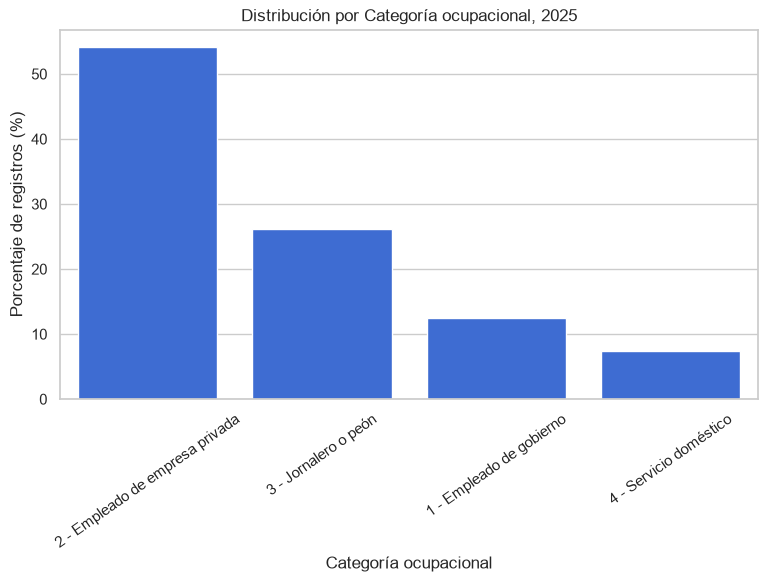

**Interpretación.** La categoría con más registros fue `2 - Empleado de empresa privada` (28,702 registros; 54.13%). La figura describe la composición de los registros elegibles, sin ponderación.

DataFrame[nivel_educativo: string, n: bigint, porcentaje: double]

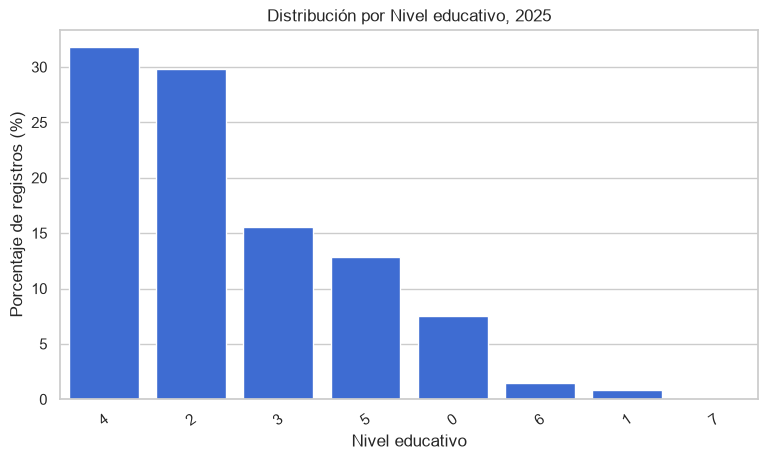

**Interpretación.** La categoría con más registros fue `4` (16,851 registros; 31.78%). La figura describe la composición de los registros elegibles, sin ponderación.

DataFrame[dominio: string, n: bigint, porcentaje: double]

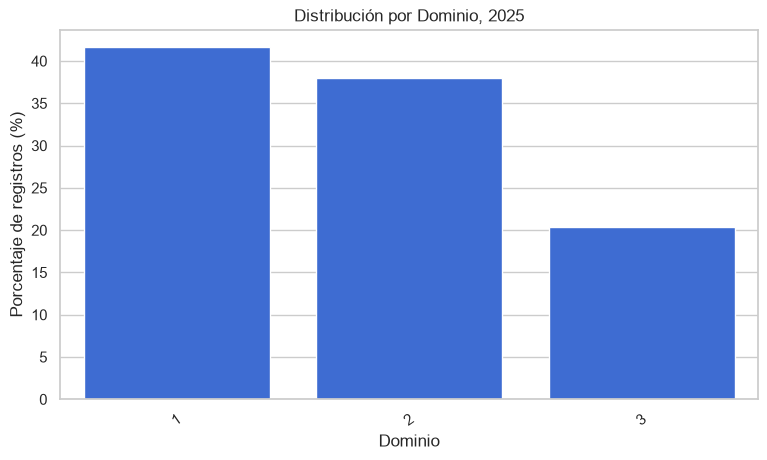

**Interpretación.** La categoría con más registros fue `1` (22,072 registros; 41.63%). La figura describe la composición de los registros elegibles, sin ponderación.

WindowsPath('C:/Users/josem/Introucci-n-a-Spark---Avances/outputs/tables/categorical_distributions_2025.csv')

In [10]:
def categorical_distribution(frame, column):
    total = frame.count()
    return (
        frame.groupBy(column).agg(F.count("*").alias("n"))
        .withColumn("porcentaje", F.lit(100.0) * F.col("n") / F.lit(total))
        .orderBy(F.desc("n"), F.asc(column))
    )

categorical_outputs = []
categorical_leaders = {}
for column, title in [
    ("categoria_ocupacional_etiqueta", "Categoría ocupacional"),
    ("nivel_educativo", "Nivel educativo"),
    ("dominio", "Dominio"),
]:
    distribution = categorical_distribution(df_2025_prepared, column)
    categorical_outputs.append(distribution.withColumn("variable", F.lit(column)))
    display(distribution)
    plot_data = aggregate_to_pandas(distribution)
    top = plot_data.iloc[0]
    categorical_leaders[column] = {
        "categoria": str(top[column]),
        "n": int(top["n"]),
        "porcentaje": float(top["porcentaje"]),
    }
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.barplot(data=plot_data, x=column, y="porcentaje", color="#2563EB", ax=ax)
    ax.set_title(f"Distribución por {title}, 2025")
    ax.set_xlabel(title)
    ax.set_ylabel("Porcentaje de registros (%)")
    ax.tick_params(axis="x", rotation=35)
    save_figure(fig, f"distribucion_{column}_2025.png")
    plt.show()
    display(Markdown(
        f"**Interpretación.** La categoría con más registros fue `{top[column]}` "
        f"({int(top['n']):,} registros; {top['porcentaje']:.2f}%). "
        "La figura describe la composición de los registros elegibles, sin ponderación."
    ))

categorical_table = categorical_outputs[0]
for output in categorical_outputs[1:]:
    categorical_table = categorical_table.unionByName(output, allowMissingColumns=True)
write_small_table(categorical_table, TABLES / "categorical_distributions_2025.csv")


## Distribución del salario mensual


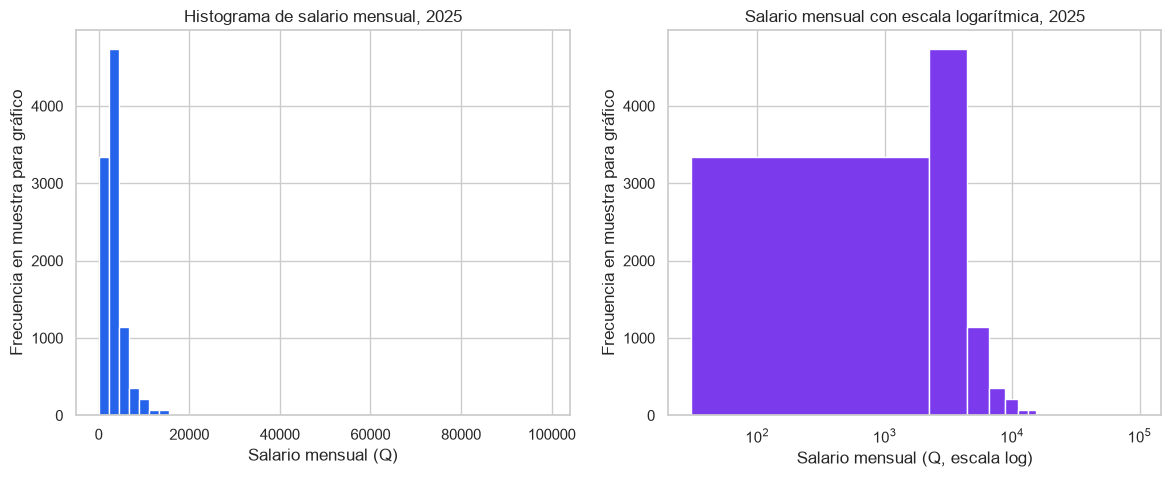

**Interpretación.** La mediana de salario calculada sobre todos los registros elegibles fue Q3,000.00. La segunda vista facilita observar la parte concentrada de la distribución sin recortar valores extremos.

In [11]:
salary_sample = bounded_sample_to_pandas(
    df_2025_prepared.select("salario_mensual"), max_rows=10_000
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(salary_sample["salario_mensual"], bins=45, color="#2563EB", edgecolor="white")
axes[0].set_title("Histograma de salario mensual, 2025")
axes[0].set_xlabel("Salario mensual (Q)")
axes[0].set_ylabel("Frecuencia en muestra para gráfico")
axes[1].hist(salary_sample["salario_mensual"], bins=45, color="#7C3AED", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Salario mensual con escala logarítmica, 2025")
axes[1].set_xlabel("Salario mensual (Q, escala log)")
axes[1].set_ylabel("Frecuencia en muestra para gráfico")
save_figure(fig, "histograma_salario_2025.png")
plt.show()
display(Markdown(
    f"**Interpretación.** La mediana de salario calculada sobre todos los registros "
    f"elegibles fue Q{salary_median_2025:,.2f}. La segunda vista facilita observar "
    "la parte concentrada de la distribución sin recortar valores extremos."
))


## Medianas salariales y evolución trimestral


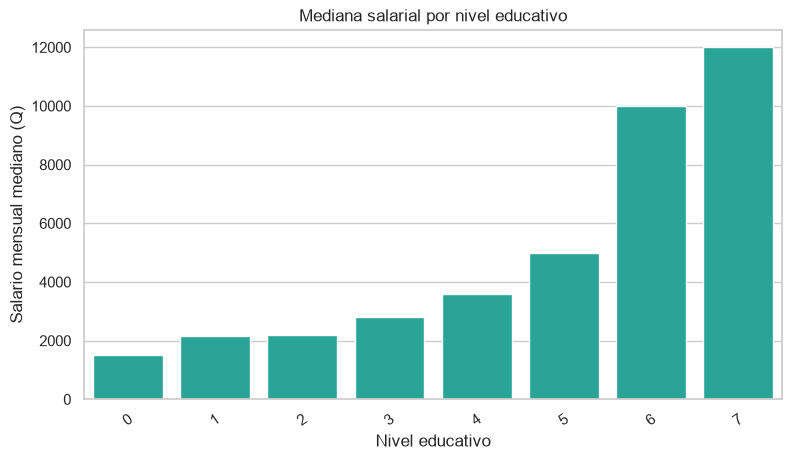

**Interpretación.** La mayor mediana observada en esta comparación fue Q12,000.00 para `7`. Es una descripción de grupos y no una atribución causal.

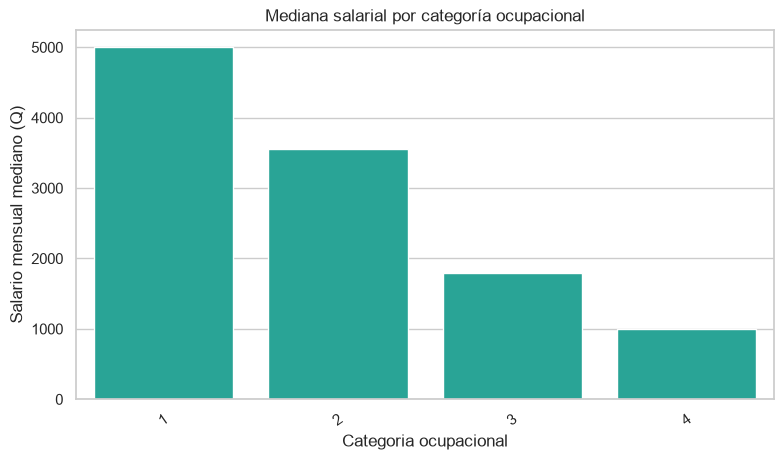

**Interpretación.** La mayor mediana observada en esta comparación fue Q5,000.00 para `1`. Es una descripción de grupos y no una atribución causal.

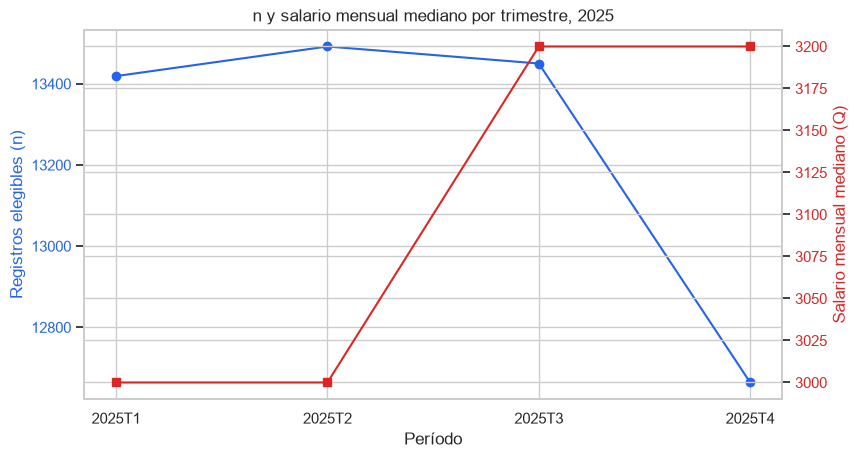

**Interpretación.** La línea azul muestra la cantidad de registros analíticos y la roja la mediana salarial de cada trimestre. Las variaciones se reportan como cambios observados entre períodos, no como efectos causales.

In [12]:
education_salary = median_by_group(df_2025_prepared, "nivel_educativo").orderBy("nivel_educativo")
occupation_salary = median_by_group(df_2025_prepared, "categoria_ocupacional").orderBy("categoria_ocupacional")
temporal_salary = (
    df_2025_prepared.groupBy("periodo_archivo", "trimestre_calendario")
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx("salario_mensual", 0.5, 10_000).alias("mediana_salario"),
    )
    .orderBy("trimestre_calendario")
)
write_small_table(education_salary, TABLES / "median_salary_by_education.csv")
write_small_table(occupation_salary, TABLES / "median_salary_by_occupation.csv")
write_small_table(temporal_salary, TABLES / "quarterly_count_and_median_salary.csv")

for frame, column, title, file_name in [
    (education_salary, "nivel_educativo", "Mediana salarial por nivel educativo", "mediana_salario_educacion_2025.png"),
    (occupation_salary, "categoria_ocupacional", "Mediana salarial por categoría ocupacional", "mediana_salario_categoria_2025.png"),
]:
    plot_data = aggregate_to_pandas(frame)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.barplot(data=plot_data, x=column, y="mediana_salario", color="#14B8A6", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(column.replace("_", " ").capitalize())
    ax.set_ylabel("Salario mensual mediano (Q)")
    ax.tick_params(axis="x", rotation=35)
    save_figure(fig, file_name)
    plt.show()
    top = plot_data.loc[plot_data["mediana_salario"].idxmax()]
    display(Markdown(
        f"**Interpretación.** La mayor mediana observada en esta comparación fue "
        f"Q{top['mediana_salario']:,.2f} para `{top[column]}`. Es una descripción "
        "de grupos y no una atribución causal."
    ))

temporal_plot = aggregate_to_pandas(temporal_salary)
temporal_first = temporal_plot.iloc[0]
temporal_last = temporal_plot.iloc[-1]
temporal_median_delta = float(
    temporal_last["mediana_salario"] - temporal_first["mediana_salario"]
)
fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.plot(temporal_plot["periodo_archivo"], temporal_plot["n"], marker="o", color="#2563EB", label="n")
ax1.set_xlabel("Período")
ax1.set_ylabel("Registros elegibles (n)", color="#2563EB")
ax1.tick_params(axis="y", labelcolor="#2563EB")
ax2 = ax1.twinx()
ax2.plot(temporal_plot["periodo_archivo"], temporal_plot["mediana_salario"], marker="s", color="#DC2626", label="mediana")
ax2.set_ylabel("Salario mensual mediano (Q)", color="#DC2626")
ax2.tick_params(axis="y", labelcolor="#DC2626")
ax1.set_title("n y salario mensual mediano por trimestre, 2025")
save_figure(fig, "n_y_mediana_salario_trimestre_2025.png")
plt.show()
display(Markdown(
    "**Interpretación.** La línea azul muestra la cantidad de registros analíticos y "
    "la roja la mediana salarial de cada trimestre. Las variaciones se reportan como "
    "cambios observados entre períodos, no como efectos causales."
))


# 3. Relaciones entre variables numéricas

La correlación de Pearson se calcula con `VectorAssembler` y
`Correlation.corr()` sobre todos los registros elegibles de 2025.


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000000,0.147249,0.179574,0.075665
edad,0.147249,1.000000,0.486713,-0.105378
antiguedad,0.179574,0.486713,1.000000,-0.062256
horas_semanales,0.075665,-0.105378,-0.062256,1.000000


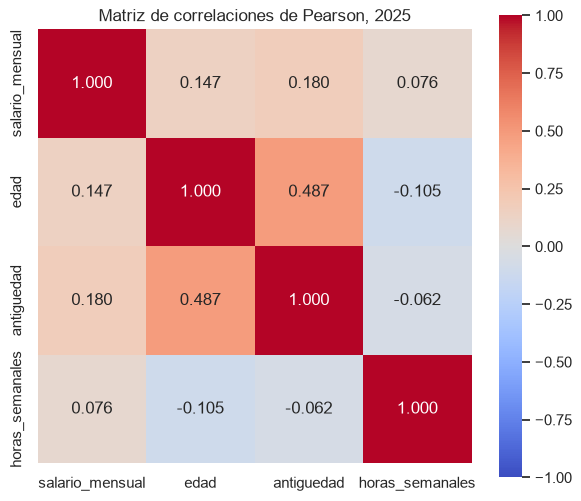

**Interpretación.** La asociación lineal de mayor magnitud con salario mensual fue `antiguedad` (r = 0.180). La relación entre edad y antigüedad fue r = 0.487. Ambos coeficientes resumen asociación lineal y no causalidad.

In [13]:
CORRELATION_COLUMNS = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
correlation_input = VectorAssembler(
    inputCols=CORRELATION_COLUMNS,
    outputCol="correlation_features",
    handleInvalid="error",
).transform(df_2025_prepared)
correlation_matrix = Correlation.corr(
    correlation_input, "correlation_features", "pearson"
).head()[0].toArray()
correlation_table = pd.DataFrame(
    correlation_matrix, index=CORRELATION_COLUMNS, columns=CORRELATION_COLUMNS
)
display(correlation_table)
correlation_table.to_csv(TABLES / "correlation_matrix.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    correlation_table, annot=True, fmt=".3f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True, ax=ax,
)
ax.set_title("Matriz de correlaciones de Pearson, 2025")
save_figure(fig, "correlation_heatmap_2025.png")
plt.show()

salary_correlations = correlation_table.loc["salario_mensual"].drop("salario_mensual")
strongest_variable = salary_correlations.abs().idxmax()
strongest_value = float(salary_correlations[strongest_variable])
age_tenure_correlation = float(correlation_table.loc["edad", "antiguedad"])
display(Markdown(
    f"**Interpretación.** La asociación lineal de mayor magnitud con salario mensual "
    f"fue `{strongest_variable}` (r = {strongest_value:.3f}). La relación entre edad "
    f"y antigüedad fue r = {age_tenure_correlation:.3f}. Ambos coeficientes resumen "
    "asociación lineal y no causalidad."
))


# 4. Segmentación mediante KMeans

El vector de clustering contiene solamente edad, antigüedad y horas
semanales. El salario no se incluye al formar los clusters para evitar
que su alta dispersión determine directamente los perfiles; se usa
después para describirlos.


+---+-------------------+
|k  |silhouette         |
+---+-------------------+
|2  |0.5544815141856185 |
|3  |0.41286676190213484|
|4  |0.4798684300228092 |
|5  |0.48377849456566524|
+---+-------------------+



K seleccionado: 2; silhouette: 0.5545


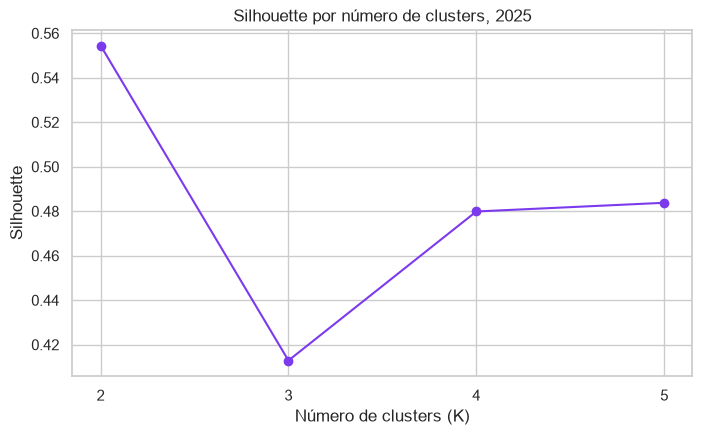

**Decisión.** Se seleccionó K = 2 porque obtuvo la mayor silhouette calculada (0.5545); ante empate se habría preferido el K menor.

In [14]:
kmeans_features, kmeans_assembler, kmeans_scaler = prepare_kmeans_features(
    df_2025_prepared,
    feature_columns=["edad", "antiguedad", "horas_semanales"],
    unscaled_col="features_unscaled",
    features_col="features",
    with_mean=True,
    with_std=True,
)
kmeans_features = kmeans_features.cache()
kmeans_n = kmeans_features.count()
if kmeans_n < 6:
    raise ValueError("KMeans requiere al menos seis registros elegibles.")

kmeans_models = {}
kmeans_rows = []
for k in (2, 3, 4, 5):
    if k >= kmeans_n:
        continue
    model = KMeans(
        k=k, seed=SEED, featuresCol="features", predictionCol="cluster"
    ).fit(kmeans_features)
    predictions = model.transform(kmeans_features)
    silhouette = float(
        ClusteringEvaluator(
            predictionCol="cluster", featuresCol="features", metricName="silhouette"
        ).evaluate(predictions)
    )
    kmeans_models[k] = model
    kmeans_rows.append({"k": k, "silhouette": silhouette})

kmeans_scores = spark.createDataFrame(kmeans_rows).orderBy("k")
kmeans_scores.show(truncate=False)
write_small_table(kmeans_scores, TABLES / "kmeans_scores.csv")
kmeans_scores_pd = aggregate_to_pandas(kmeans_scores)
best_k = int(kmeans_scores_pd.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
best_silhouette = float(kmeans_scores_pd.loc[kmeans_scores_pd["k"] == best_k, "silhouette"].iloc[0])
best_predictions = kmeans_models[best_k].transform(kmeans_features).cache()
print(f"K seleccionado: {best_k}; silhouette: {best_silhouette:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(kmeans_scores_pd["k"], kmeans_scores_pd["silhouette"], marker="o", color="#7C3AED")
ax.set_title("Silhouette por número de clusters, 2025")
ax.set_xlabel("Número de clusters (K)")
ax.set_ylabel("Silhouette")
ax.set_xticks([2, 3, 4, 5])
save_figure(fig, "kmeans_silhouette_vs_k_2025.png")
plt.show()
display(Markdown(
    f"**Decisión.** Se seleccionó K = {best_k} porque obtuvo la mayor silhouette "
    f"calculada ({best_silhouette:.4f}); ante empate se habría preferido el K menor."
))


## Caracterización y visualización de clusters


+-------+-----+------------------+------------+------------------+------------------+-----------------+-------------+------------------+---------------+------------------+
|cluster|n    |edad_media        |edad_mediana|antiguedad_media  |antiguedad_mediana|horas_media      |horas_mediana|salario_media     |salario_mediana|porcentaje        |
+-------+-----+------------------+------------+------------------+------------------+-----------------+-------------+------------------+---------------+------------------+
|0      |14604|51.279101615995614|51.0        |13.805024879028574|13.0              |41.29553546973432|40.0         |4068.515269789099 |3466.0         |27.541725601131542|
|1      |38421|29.071211056453503|28.0        |2.4244098279586717|1.3333333333333333|48.21243590744645|46.0         |3175.8207230420862|3000.0         |72.45827439886845 |
+-------+-----+------------------+------------+------------------+------------------+-----------------+-------------+------------------+----

Resumen de nivel_educativo por cluster:


+-------+---------------+-----+---------+--------------------+
|cluster|nivel_educativo|n    |n_cluster|porcentaje_cluster  |
+-------+---------------+-----+---------+--------------------+
|0      |2              |4749 |14604    |32.51848808545604   |
|0      |4              |3295 |14604    |22.56231169542591   |
|0      |5              |2491 |14604    |17.05697069296083   |
|0      |0              |2116 |14604    |14.489181046288689  |
|0      |3              |1392 |14604    |9.531635168447      |
|0      |6              |345  |14604    |2.3623664749383733  |
|0      |1              |168  |14604    |1.1503697617091209  |
|0      |7              |48   |14604    |0.3286770747740345  |
|1      |4              |13556|38421    |35.28278805861378   |
|1      |2              |11073|38421    |28.820176465995157  |
|1      |3              |6857 |38421    |17.847010749329794  |
|1      |5              |4327 |38421    |11.262070222014003  |
|1      |0              |1879 |38421    |4.890554644595

Resumen de categoria_ocupacional_etiqueta por cluster:


+-------+-------------------------------+-----+---------+------------------+
|cluster|categoria_ocupacional_etiqueta |n    |n_cluster|porcentaje_cluster|
+-------+-------------------------------+-----+---------+------------------+
|0      |2 - Empleado de empresa privada|6214 |14604    |42.549986305121884|
|0      |3 - Jornalero o peón           |3549 |14604    |24.301561216105178|
|0      |1 - Empleado de gobierno       |3430 |14604    |23.486715968227884|
|0      |4 - Servicio doméstico         |1411 |14604    |9.661736510545056 |
|1      |2 - Empleado de empresa privada|22488|38421    |58.53049113765909 |
|1      |3 - Jornalero o peón           |10293|38421    |26.79003669868041 |
|1      |1 - Empleado de gobierno       |3145 |38421    |8.185627651544728 |
|1      |4 - Servicio doméstico         |2495 |38421    |6.49384451211577  |
+-------+-------------------------------+-----+---------+------------------+



Resumen de dominio por cluster:


+-------+-------+-----+---------+------------------+
|cluster|dominio|n    |n_cluster|porcentaje_cluster|
+-------+-------+-----+---------+------------------+
|0      |1      |6641 |14604    |45.47384278279923 |
|0      |2      |5485 |14604    |37.558203231991236|
|0      |3      |2478 |14604    |16.967953985209533|
|1      |1      |15431|38421    |40.16293173004347 |
|1      |2      |14661|38421    |38.15881939564301 |
|1      |3      |8329 |38421    |21.678248874313528|
+-------+-------+-----+---------+------------------+



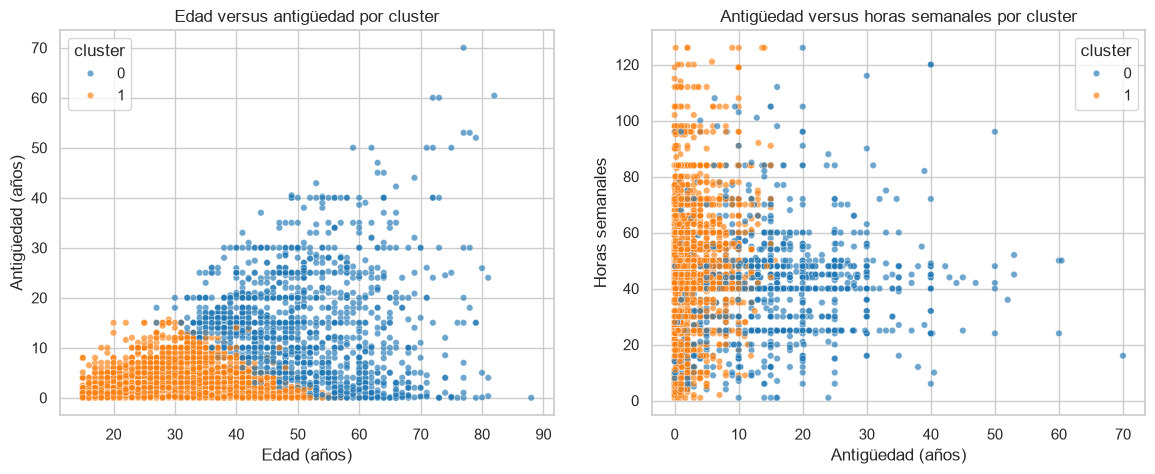

**Interpretación.** Las tablas resumen todos los registros de cada cluster; los gráficos usan como máximo 5,000 puntos solo para legibilidad. El salario se presenta como característica descriptiva posterior y no como entrada de KMeans.

In [15]:
cluster_total = best_predictions.count()
cluster_profiles = (
    best_predictions.groupBy("cluster")
    .agg(
        F.count("*").alias("n"),
        F.avg("edad").alias("edad_media"),
        F.percentile_approx("edad", 0.5, 10_000).alias("edad_mediana"),
        F.avg("antiguedad").alias("antiguedad_media"),
        F.percentile_approx("antiguedad", 0.5, 10_000).alias("antiguedad_mediana"),
        F.avg("horas_semanales").alias("horas_media"),
        F.percentile_approx("horas_semanales", 0.5, 10_000).alias("horas_mediana"),
        F.avg("salario_mensual").alias("salario_media"),
        F.percentile_approx("salario_mensual", 0.5, 10_000).alias("salario_mediana"),
    )
    .withColumn("porcentaje", F.lit(100.0) * F.col("n") / F.lit(cluster_total))
    .orderBy("cluster")
)
cluster_profiles.show(truncate=False)
write_small_table(cluster_profiles, TABLES / "cluster_profiles.csv")
cluster_profiles_pd = aggregate_to_pandas(cluster_profiles)
largest_cluster = cluster_profiles_pd.loc[cluster_profiles_pd["n"].idxmax()]

for column in ("nivel_educativo", "categoria_ocupacional_etiqueta", "dominio"):
    category_summary = (
        best_predictions.groupBy("cluster", column).agg(F.count("*").alias("n"))
        .join(best_predictions.groupBy("cluster").agg(F.count("*").alias("n_cluster")), "cluster")
        .withColumn("porcentaje_cluster", F.lit(100.0) * F.col("n") / F.col("n_cluster"))
        .orderBy("cluster", F.desc("n"), F.asc(column))
    )
    print(f"Resumen de {column} por cluster:")
    category_summary.show(100, truncate=False)
    write_small_table(category_summary, TABLES / f"cluster_{column}_summary.csv")

scatter_sample = bounded_sample_to_pandas(
    best_predictions.select("edad", "antiguedad", "horas_semanales", "cluster"), max_rows=5_000
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=scatter_sample, x="edad", y="antiguedad", hue="cluster", palette="tab10", alpha=0.65, s=22, ax=axes[0])
axes[0].set_title("Edad versus antigüedad por cluster")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Antigüedad (años)")
sns.scatterplot(data=scatter_sample, x="antiguedad", y="horas_semanales", hue="cluster", palette="tab10", alpha=0.65, s=22, ax=axes[1])
axes[1].set_title("Antigüedad versus horas semanales por cluster")
axes[1].set_xlabel("Antigüedad (años)")
axes[1].set_ylabel("Horas semanales")
save_figure(fig, "kmeans_scatter_profiles_2025.png")
plt.show()
display(Markdown(
    "**Interpretación.** Las tablas resumen todos los registros de cada cluster; "
    "los gráficos usan como máximo 5,000 puntos solo para legibilidad. El salario "
    "se presenta como característica descriptiva posterior y no como entrada de KMeans."
))


In [16]:
# Cluster tables and figures are already persisted on disk; release
# their cached feature frames before fitting supervised models.
best_predictions.unpersist()
kmeans_features.unpersist()


DataFrame[salario_mensual: double, edad: double, antiguedad_anios: double, antiguedad_meses: double, horas_semanales: double, nivel_educativo: string, categoria_ocupacional: string, dominio: string, ocupado: string, NUM_HOGAR: string, NUM_PERSONA: string, FACTOR: double, ANIO: string, TRIMESTRE: string, antiguedad: double, archivo_origen: string, periodo_archivo: string, anio_archivo: int, trimestre_calendario: int, categoria_ocupacional_etiqueta: string, features_unscaled: vector, features: vector]

# 5. Pipeline de regresión lineal

La división, el baseline y todos los ajustes de hiperparámetros usan
exclusivamente 2025. Los indexadores y codificadores se ajustan dentro
de cada pipeline sobre `train_2025`, evitando filtración de información.


In [17]:
# Los mismos conjuntos se reutilizan de forma exacta para LR y Random Forest.
train_2025, validation_2025 = df_2025_prepared.randomSplit([0.80, 0.20], seed=42)
train_2025 = train_2025.cache()
validation_2025 = validation_2025.cache()
n_train_2025 = train_2025.count()
n_validation_2025 = validation_2025.count()
if not n_train_2025 or not n_validation_2025:
    raise ValueError("La división train/validation produjo un conjunto vacío.")
print(f"train_2025: {n_train_2025:,}")
print(f"validation_2025: {n_validation_2025:,}")

train_median_salary = float(
    train_2025.agg(F.percentile_approx("salario_mensual", 0.5, 10_000).alias("mediana")).first()["mediana"]
)
baseline_validation = validation_2025.withColumn("prediction", F.lit(train_median_salary))
baseline_validation_metrics = evaluate_regression(
    baseline_validation, "salario_mensual", "prediction"
)
print("Baseline (mediana de train):", baseline_validation_metrics)
display(Markdown(
    "**Baseline.** La predicción constante se calcula con la mediana de `train_2025`, "
    "nunca con validation. MAE y RMSE son las referencias principales; R² en una "
    "predicción constante debe interpretarse con cautela porque no representa variación explicada."
))


train_2025: 42,578
validation_2025: 10,447
Baseline (mediana de train): {'MAE': 1690.0977314061454, 'RMSE': 2996.4816885972446, 'R2': -0.023993569195895237}


**Baseline.** La predicción constante se calcula con la mediana de `train_2025`, nunca con validation. MAE y RMSE son las referencias principales; R² en una predicción constante debe interpretarse con cautela porque no representa variación explicada.

In [18]:
lr_configs = [
    {"modelo": "LR_1", "regParam": 0.0, "elasticNetParam": 0.0},
    {"modelo": "LR_2", "regParam": 0.01, "elasticNetParam": 0.0},
    {"modelo": "LR_3", "regParam": 0.01, "elasticNetParam": 0.5},
]
lr_validation_models = {}
lr_validation_rows = []

for config in lr_configs:
    pipeline = build_linear_regression_pipeline(
        reg_param=config["regParam"],
        elastic_net_param=config["elasticNetParam"],
        max_iter=100,
    )
    model = pipeline.fit(train_2025)
    predictions = model.transform(validation_2025)
    metrics = evaluate_regression(predictions, "salario_mensual", "prediction")
    lr_validation_models[config["modelo"]] = model
    lr_validation_rows.append({**config, **metrics})

lr_validation_metrics = spark.createDataFrame(lr_validation_rows).orderBy("RMSE")
lr_validation_metrics.show(truncate=False)
write_small_table(lr_validation_metrics, TABLES / "lr_validation_metrics.csv")
best_lr_row = min(lr_validation_rows, key=lambda row: row["RMSE"])
best_lr_config = next(config for config in lr_configs if config["modelo"] == best_lr_row["modelo"])
best_lr_validation_model = lr_validation_models[best_lr_config["modelo"]]
best_lr_validation_model.write().overwrite().save(str(MODELS / "linear_regression_best"))
display(Markdown(
    f"**Selección LR.** `{best_lr_config['modelo']}` obtuvo el menor RMSE de validación "
    f"(Q{best_lr_row['RMSE']:,.2f}) entre las configuraciones lineales y se guardó "
    "como modelo de validación."
))


+------------------+-------------------+------------------+---------------+------+--------+
|MAE               |R2                 |RMSE              |elasticNetParam|modelo|regParam|
+------------------+-------------------+------------------+---------------+------+--------+
|1245.3199722152729|0.3996998726540013 |2294.2842894257733|0.0            |LR_1  |0.0     |
|1245.3196350013854|0.39969985431154587|2294.284324477246 |0.0            |LR_2  |0.01    |
|1245.3186806477304|0.3996998480527566 |2294.284336437465 |0.5            |LR_3  |0.01    |
+------------------+-------------------+------------------+---------------+------+--------+



**Selección LR.** `LR_1` obtuvo el menor RMSE de validación (Q2,294.28) entre las configuraciones lineales y se guardó como modelo de validación.

# 6. Pipeline Random Forest

Random Forest usa las mismas seis variables y la misma división de
2025. No se añade `StandardScaler`, pues los árboles no lo requieren.
Para mantener una ejecución local reproducible se comparan 20/5,
40/7 y 60/8 (árboles/profundidad), con histogramas internos acotados;
la selección sigue basándose exclusivamente en el RMSE de validación.


In [19]:
rf_configs = [
    {"modelo": "RF_1", "numTrees": 20, "maxDepth": 5},
    {"modelo": "RF_2", "numTrees": 40, "maxDepth": 7},
    {"modelo": "RF_3", "numTrees": 60, "maxDepth": 8},
]
rf_validation_models = {}
rf_validation_rows = []

for config in rf_configs:
    pipeline = build_random_forest_pipeline(
        num_trees=config["numTrees"], max_depth=config["maxDepth"], seed=SEED
    )
    model = pipeline.fit(train_2025)
    predictions = model.transform(validation_2025)
    metrics = evaluate_regression(predictions, "salario_mensual", "prediction")
    rf_validation_models[config["modelo"]] = model
    rf_validation_rows.append({**config, **metrics})

rf_validation_metrics = spark.createDataFrame(rf_validation_rows).orderBy("RMSE")
rf_validation_metrics.show(truncate=False)
write_small_table(rf_validation_metrics, TABLES / "rf_validation_metrics.csv")
best_rf_row = min(rf_validation_rows, key=lambda row: row["RMSE"])
best_rf_config = next(config for config in rf_configs if config["modelo"] == best_rf_row["modelo"])
best_rf_validation_model = rf_validation_models[best_rf_config["modelo"]]
best_rf_validation_model.write().overwrite().save(str(MODELS / "random_forest_best"))

importance_frame = best_rf_validation_model.transform(validation_2025)
rf_importances = feature_importance_table(
    best_rf_validation_model.stages[-1], importance_frame, features_col="features"
)
display(rf_importances)
rf_importances.to_csv(TABLES / "rf_feature_importances.csv", index=False, encoding="utf-8-sig")
display(Markdown(
    f"**Selección RF.** `{best_rf_config['modelo']}` obtuvo el menor RMSE de validación "
    f"(Q{best_rf_row['RMSE']:,.2f}). Las variables categóricas se expanden en varias "
    "dimensiones one-hot; cuando Spark no expone el nombre de una dimensión, la tabla "
    "reporta solo su posición y no infiere una categoría."
))


+------------------+-------------------+------------------+--------+------+--------+
|MAE               |R2                 |RMSE              |maxDepth|modelo|numTrees|
+------------------+-------------------+------------------+--------+------+--------+
|1134.7010471015064|0.45969520520643015|2176.6190420735734|8       |RF_3  |60      |
|1146.0912627805856|0.44950195167163687|2197.054880116552 |7       |RF_2  |40      |
|1197.827188758176 |0.41056684159936985|2273.4232393901916|5       |RF_1  |20      |
+------------------+-------------------+------------------+--------+------+--------+



,indice,feature,importancia
0,8,nivel_educativo__ohe_6,0.212157
1,6,nivel_educativo__ohe_5,0.167113
2,14,categoria_ocupacional__ohe_1,0.118393
3,13,categoria_ocupacional__ohe_3,0.090263
4,2,horas_semanales,0.073810
5,0,edad,0.073404
6,12,categoria_ocupacional__ohe_2,0.056720
7,1,antiguedad,0.050797
8,15,categoria_ocupacional__ohe_4,0.044061
9,17,dominio__ohe_1,0.029596


**Selección RF.** `RF_3` obtuvo el menor RMSE de validación (Q2,176.62). Las variables categóricas se expanden en varias dimensiones one-hot; cuando Spark no expone el nombre de una dimensión, la tabla reporta solo su posición y no infiere una categoría.

## Comparación de validación


In [20]:
validation_comparison_rows = [
    {"modelo": "Baseline", "dataset": "validation_2025", **baseline_validation_metrics},
    {"modelo": "Linear Regression", "dataset": "validation_2025", **{key: best_lr_row[key] for key in ("MAE", "RMSE", "R2")}},
    {"modelo": "Random Forest", "dataset": "validation_2025", **{key: best_rf_row[key] for key in ("MAE", "RMSE", "R2")}},
]
validation_comparison = spark.createDataFrame(validation_comparison_rows).orderBy("RMSE")
validation_comparison.show(truncate=False)
write_small_table(validation_comparison, TABLES / "model_comparison_validation.csv")
validation_winner = min(validation_comparison_rows, key=lambda row: row["RMSE"])
mae_winner = min(validation_comparison_rows, key=lambda row: row["MAE"])
display(Markdown(
    f"**Interpretación.** El menor RMSE de validación fue `{validation_winner['modelo']}` "
    f"(Q{validation_winner['RMSE']:,.2f}) y el menor MAE fue `{mae_winner['modelo']}` "
    f"(Q{mae_winner['MAE']:,.2f}). Las diferencias de R² se muestran en la tabla; "
    "pueden reflejar flexibilidad del modelo y patrones no lineales, no relaciones causales."
))


+------------------+---------------------+------------------+---------------+-----------------+
|MAE               |R2                   |RMSE              |dataset        |modelo           |
+------------------+---------------------+------------------+---------------+-----------------+
|1134.7010471015064|0.45969520520643015  |2176.6190420735734|validation_2025|Random Forest    |
|1245.3199722152729|0.3996998726540013   |2294.2842894257733|validation_2025|Linear Regression|
|1690.0977314061454|-0.023993569195895237|2996.4816885972446|validation_2025|Baseline         |
+------------------+---------------------+------------------+---------------+-----------------+



**Interpretación.** El menor RMSE de validación fue `Random Forest` (Q2,176.62) y el menor MAE fue `Random Forest` (Q1,134.70). Las diferencias de R² se muestran en la tabla; pueden reflejar flexibilidad del modelo y patrones no lineales, no relaciones causales.

# 7. Entrenamiento final y evaluación en I-2026

Una vez seleccionadas las configuraciones usando sólo la validación de
2025, los pipelines completos se ajustan nuevamente con todos los
registros elegibles de 2025. I-2026 no participa al ajustar indexadores,
codificadores, KMeans ni hiperparámetros.


In [21]:
train_final = df_2025_prepared
final_median_salary = float(
    train_final.agg(F.percentile_approx("salario_mensual", 0.5, 10_000).alias("mediana")).first()["mediana"]
)

final_lr_model = build_linear_regression_pipeline(
    reg_param=best_lr_config["regParam"],
    elastic_net_param=best_lr_config["elasticNetParam"],
    max_iter=100,
).fit(train_final)
final_rf_model = build_random_forest_pipeline(
    num_trees=best_rf_config["numTrees"],
    max_depth=best_rf_config["maxDepth"],
    seed=SEED,
).fit(train_final)
final_lr_model.write().overwrite().save(str(MODELS / "linear_regression_final"))
final_rf_model.write().overwrite().save(str(MODELS / "random_forest_final"))

# Estas son exactamente las mismas filas elegibles de I-2026 para ambos modelos.
pred_lr_2026 = final_lr_model.transform(df_2026_prepared).cache()
pred_rf_2026 = final_rf_model.transform(df_2026_prepared).cache()
n_test_lr = pred_lr_2026.count()
n_test_rf = pred_rf_2026.count()
if n_test_lr != n_test_rf or n_test_lr != n_2026_prepared:
    raise AssertionError("Los modelos no recibieron exactamente el mismo test I-2026.")

baseline_2026 = df_2026_prepared.withColumn("prediction", F.lit(final_median_salary))
baseline_test_metrics = evaluate_regression(baseline_2026, "salario_mensual", "prediction")
lr_test_metrics = evaluate_regression(pred_lr_2026, "salario_mensual", "prediction")
rf_test_metrics = evaluate_regression(pred_rf_2026, "salario_mensual", "prediction")

test_comparison_rows = [
    {"modelo": "Baseline", "dataset": "test_2026", **baseline_test_metrics},
    {"modelo": "Linear Regression", "dataset": "test_2026", **lr_test_metrics},
    {"modelo": "Random Forest", "dataset": "test_2026", **rf_test_metrics},
]
test_comparison = spark.createDataFrame(test_comparison_rows).orderBy("RMSE")
test_comparison.show(truncate=False)
write_small_table(test_comparison, TABLES / "model_comparison_test_2026.csv")
test_winner = min(test_comparison_rows, key=lambda row: row["RMSE"])

# Compare the same baseline and selected pipelines without using I-2026
# to alter any decision made during validation.
validation_lookup = {
    "Baseline": baseline_validation_metrics,
    "Linear Regression": {key: best_lr_row[key] for key in ("MAE", "RMSE", "R2")},
    "Random Forest": {key: best_rf_row[key] for key in ("MAE", "RMSE", "R2")},
}
test_lookup = {
    "Baseline": baseline_test_metrics,
    "Linear Regression": lr_test_metrics,
    "Random Forest": rf_test_metrics,
}
validation_vs_test_rows = []
for model_name in ("Baseline", "Linear Regression", "Random Forest"):
    validation_metrics = validation_lookup[model_name]
    test_metrics = test_lookup[model_name]
    validation_vs_test_rows.append({
        "modelo": model_name,
        "MAE_validacion_2025": validation_metrics["MAE"],
        "MAE_test_2026": test_metrics["MAE"],
        "delta_MAE": test_metrics["MAE"] - validation_metrics["MAE"],
        "RMSE_validacion_2025": validation_metrics["RMSE"],
        "RMSE_test_2026": test_metrics["RMSE"],
        "delta_RMSE": test_metrics["RMSE"] - validation_metrics["RMSE"],
        "R2_validacion_2025": validation_metrics["R2"],
        "R2_test_2026": test_metrics["R2"],
        "delta_R2": test_metrics["R2"] - validation_metrics["R2"],
    })
validation_vs_test = spark.createDataFrame(validation_vs_test_rows).orderBy("modelo")
validation_vs_test.show(truncate=False)
write_small_table(validation_vs_test, TABLES / "validation_vs_test.csv")
comparison_all_periods = spark.createDataFrame(
    [*validation_comparison_rows, *test_comparison_rows]
).select("modelo", "dataset", "MAE", "RMSE", "R2").orderBy("modelo", "dataset")
comparison_all_periods.show(truncate=False)
write_small_table(
    comparison_all_periods, TABLES / "model_comparison_validation_vs_test.csv"
)
stability_by_model = {row["modelo"]: row for row in validation_vs_test_rows}
stability_notes = []
performance_notes = []
for row in validation_vs_test_rows:
    direction = "aumentó" if row["delta_RMSE"] > 0 else "disminuyó" if row["delta_RMSE"] < 0 else "no cambió"
    stability_notes.append(
        f"{row['modelo']}: RMSE {direction} Q{abs(row['delta_RMSE']):,.2f}"
    )
    performance_notes.append(
        f"{row['modelo']}: validación MAE/RMSE Q{row['MAE_validacion_2025']:,.2f}/Q{row['RMSE_validacion_2025']:,.2f}; "
        f"I-2026 Q{row['MAE_test_2026']:,.2f}/Q{row['RMSE_test_2026']:,.2f}"
    )
display(Markdown(
    f"**Evaluación final.** I-2026 se evaluó con {n_test_lr:,} registros elegibles. "
    f"El menor RMSE final fue `{test_winner['modelo']}` (Q{test_winner['RMSE']:,.2f}). "
    "Comparación validación→test: " + "; ".join(stability_notes) + ". "
    "Estos cambios describen estabilidad o degradación temporal y no se usaron "
    "para cambiar configuraciones."
))


+------------------+--------------------+------------------+---------+-----------------+
|MAE               |R2                  |RMSE              |dataset  |modelo           |
+------------------+--------------------+------------------+---------+-----------------+
|1130.406866321447 |0.5054480573601431  |2016.764215242486 |test_2026|Random Forest    |
|1240.7105465716627|0.4307323509027091  |2163.751702974567 |test_2026|Linear Regression|
|1718.6783074370192|-0.03892430782659284|2923.0828473640513|test_2026|Baseline         |
+------------------+--------------------+------------------+---------+-----------------+



+------------------+-------------------+--------------------+---------------------+------------------+--------------------+------------------+---------------------+------------------+-----------------+
|MAE_test_2026     |MAE_validacion_2025|R2_test_2026        |R2_validacion_2025   |RMSE_test_2026    |RMSE_validacion_2025|delta_MAE         |delta_R2             |delta_RMSE        |modelo           |
+------------------+-------------------+--------------------+---------------------+------------------+--------------------+------------------+---------------------+------------------+-----------------+
|1718.6783074370192|1690.0977314061454 |-0.03892430782659284|-0.023993569195895237|2923.0828473640513|2996.4816885972446  |28.58057603087377 |-0.014930738630697604|-73.39884123319325|Baseline         |
|1240.7105465716627|1245.3199722152729 |0.4307323509027091  |0.3996998726540013   |2163.751702974567 |2294.2842894257733  |-4.609425643610166|0.031032478248707807 |-130.5325864512065|Linear Re

+-----------------+---------------+------------------+------------------+---------------------+
|modelo           |dataset        |MAE               |RMSE              |R2                   |
+-----------------+---------------+------------------+------------------+---------------------+
|Baseline         |test_2026      |1718.6783074370192|2923.0828473640513|-0.03892430782659284 |
|Baseline         |validation_2025|1690.0977314061454|2996.4816885972446|-0.023993569195895237|
|Linear Regression|test_2026      |1240.7105465716627|2163.751702974567 |0.4307323509027091   |
|Linear Regression|validation_2025|1245.3199722152729|2294.2842894257733|0.3996998726540013   |
|Random Forest    |test_2026      |1130.406866321447 |2016.764215242486 |0.5054480573601431   |
|Random Forest    |validation_2025|1134.7010471015064|2176.6190420735734|0.45969520520643015  |
+-----------------+---------------+------------------+------------------+---------------------+



**Evaluación final.** I-2026 se evaluó con 13,258 registros elegibles. El menor RMSE final fue `Random Forest` (Q2,016.76). Comparación validación→test: Baseline: RMSE disminuyó Q73.40; Linear Regression: RMSE disminuyó Q130.53; Random Forest: RMSE disminuyó Q159.85. Estos cambios describen estabilidad o degradación temporal y no se usaron para cambiar configuraciones.

# 8. Visualización y análisis de errores

Se define `residuo = salario_mensual - prediction`: un residuo positivo
significa que el modelo subestimó el salario y uno negativo que lo
sobreestimó. Las métricas de grupos usan todo I-2026; solo los gráficos
usan una muestra común de como máximo 5,000 registros.


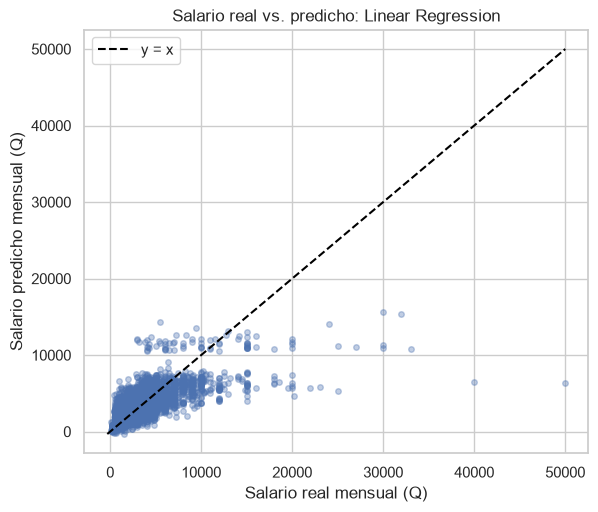

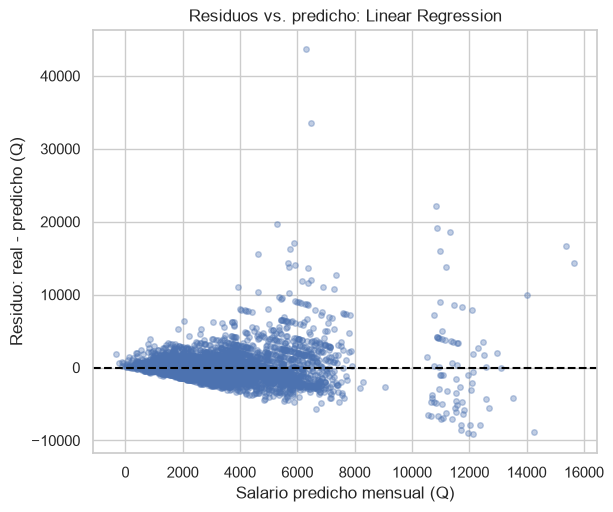

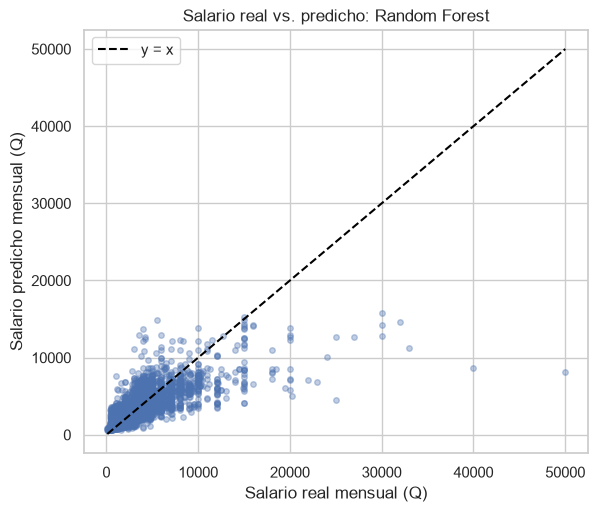

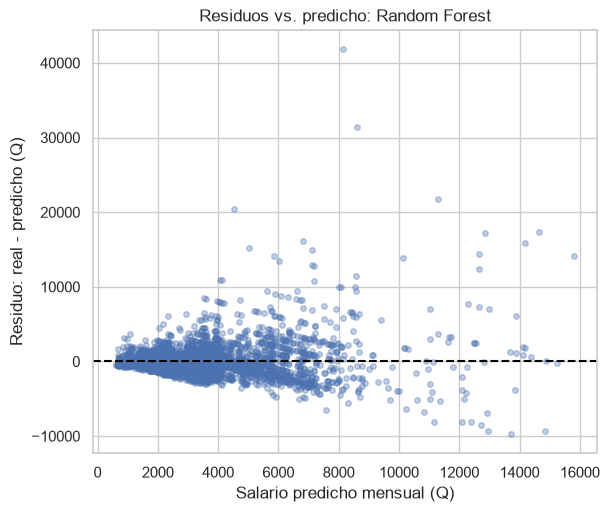

**Interpretación.** Ambos pares de gráficos usan la misma muestra determinista de 5,000 registros. La recta y=x representa predicción perfecta y la línea horizontal de residuos permite observar subestimación (positivo) u sobreestimación (negativo).

In [22]:
common_plot_sample = deterministic_sample(
    df_2026_prepared,
    max_rows=5_000,
    seed=SEED,
    key_columns=("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"),
)
plot_lr_2026 = with_residual(final_lr_model.transform(common_plot_sample))
plot_rf_2026 = with_residual(final_rf_model.transform(common_plot_sample))
plot_lr_pd = plot_lr_2026.select("salario_mensual", "prediction", "residuo").toPandas()
plot_rf_pd = plot_rf_2026.select("salario_mensual", "prediction", "residuo").toPandas()

def prediction_plots(plot_data, model_name, stem):
    lower = min(plot_data["salario_mensual"].min(), plot_data["prediction"].min())
    upper = max(plot_data["salario_mensual"].max(), plot_data["prediction"].max())
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.scatter(plot_data["salario_mensual"], plot_data["prediction"], alpha=0.35, s=16)
    ax.plot([lower, upper], [lower, upper], color="black", linestyle="--", label="y = x")
    ax.set_title(f"Salario real vs. predicho: {model_name}")
    ax.set_xlabel("Salario real mensual (Q)")
    ax.set_ylabel("Salario predicho mensual (Q)")
    ax.legend()
    save_figure(fig, f"real_vs_predicho_{stem}_2026.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.scatter(plot_data["prediction"], plot_data["residuo"], alpha=0.35, s=16)
    ax.axhline(0, color="black", linestyle="--")
    ax.set_title(f"Residuos vs. predicho: {model_name}")
    ax.set_xlabel("Salario predicho mensual (Q)")
    ax.set_ylabel("Residuo: real - predicho (Q)")
    save_figure(fig, f"residuos_vs_predicho_{stem}_2026.png")
    plt.show()

prediction_plots(plot_lr_pd, "Linear Regression", "linear_regression")
prediction_plots(plot_rf_pd, "Random Forest", "random_forest")
display(Markdown(
    f"**Interpretación.** Ambos pares de gráficos usan la misma muestra determinista de "
    f"{len(plot_lr_pd):,} registros. La recta y=x representa predicción perfecta y la "
    "línea horizontal de residuos permite observar subestimación (positivo) u "
    "sobreestimación (negativo)."
))


## Métricas de error por nivel educativo y dominio


In [23]:
pred_lr_2026_error = with_residual(pred_lr_2026).cache()
pred_rf_2026_error = with_residual(pred_rf_2026).cache()

def combine_group_metrics(group_column):
    lr_group = grouped_error_metrics(pred_lr_2026_error, group_column).withColumn(
        "modelo", F.lit("Linear Regression")
    )
    rf_group = grouped_error_metrics(pred_rf_2026_error, group_column).withColumn(
        "modelo", F.lit("Random Forest")
    )
    return lr_group.unionByName(rf_group).select("modelo", group_column, "n", "MAE", "error_medio")

errors_by_education = combine_group_metrics("nivel_educativo")
errors_by_domain = combine_group_metrics("dominio")
errors_by_education.show(100, truncate=False)
errors_by_domain.show(100, truncate=False)
write_small_table(errors_by_education, TABLES / "errors_by_education.csv")
write_small_table(errors_by_domain, TABLES / "errors_by_domain.csv")
education_errors_pd = aggregate_to_pandas(errors_by_education)
domain_errors_pd = aggregate_to_pandas(errors_by_domain)
segment_error_notes = []
for model_name in ("Linear Regression", "Random Forest"):
    education_worst = education_errors_pd.loc[
        education_errors_pd["modelo"] == model_name
    ].sort_values("MAE", ascending=False).iloc[0]
    domain_worst = domain_errors_pd.loc[
        domain_errors_pd["modelo"] == model_name
    ].sort_values("MAE", ascending=False).iloc[0]
    segment_error_notes.append(
        f"{model_name}: mayor MAE por educación en `{education_worst['nivel_educativo']}` "
        f"(Q{education_worst['MAE']:,.2f}; n={int(education_worst['n']):,}) y por dominio "
        f"en `{domain_worst['dominio']}` (Q{domain_worst['MAE']:,.2f}; n={int(domain_worst['n']):,})"
    )
display(Markdown(
    "**Interpretación.** `error_medio` positivo indica subestimación promedio y negativo "
    "sobreestimación promedio. " + "; ".join(segment_error_notes) + ". "
    "Las tablas usan todo el test I-2026, no la muestra gráfica."
))


+-----------------+---------------+----+------------------+-------------------+
|modelo           |nivel_educativo|n   |MAE               |error_medio        |
+-----------------+---------------+----+------------------+-------------------+
|Linear Regression|4              |4117|1109.3142466276386|103.97732071280355 |
|Linear Regression|2              |3957|870.0358173744414 |54.5553590337862   |
|Linear Regression|3              |2164|894.451483055286  |127.76970455270818 |
|Linear Regression|5              |1729|2566.3704572105753|295.514038681838   |
|Linear Regression|0              |1016|823.5131164082695 |109.34029889060436 |
|Linear Regression|6              |183 |5552.879063507153 |-131.50427745870724|
|Linear Regression|1              |80  |735.2063474690442 |88.76187301928901  |
|Linear Regression|7              |12  |12919.309265966616|6062.703551890022  |
|Random Forest    |4              |4117|1036.683089409789 |201.13199487767332 |
|Random Forest    |2              |3957|

**Interpretación.** `error_medio` positivo indica subestimación promedio y negativo sobreestimación promedio. Linear Regression: mayor MAE por educación en `7` (Q12,919.31; n=12) y por dominio en `1` (Q1,446.09; n=5,632); Random Forest: mayor MAE por educación en `7` (Q12,824.93; n=12) y por dominio en `1` (Q1,340.30; n=5,632). Las tablas usan todo el test I-2026, no la muestra gráfica.

## Errores según bandas de salario real


+-----------------+-------------+----+------------------+---------------+------------------+-----------------+------------------+-------------------+--------------------+
|modelo           |banda_salario|n   |salario_medio     |salario_mediano|prediccion_media  |MAE              |RMSE              |error_medio        |error_medio_absoluto|
+-----------------+-------------+----+------------------+---------------+------------------+-----------------+------------------+-------------------+--------------------+
|Linear Regression|p0-p25       |4032|1297.6803075396826|1200.0         |2126.4105578407534|998.3881384754002|1333.762338108071 |-828.7302503010712 |998.3881384754002   |
|Linear Regression|p25-p50      |2715|2738.186740331492 |2800.0         |2899.272181342612 |851.6759460785308|1158.0684241389513|-161.08544101111855|851.6759460785308   |
|Linear Regression|p50-p75      |3188|3769.052070263488 |3800.0         |3848.695916559118 |830.8179588351346|1200.2346314701833|-79.643846295629

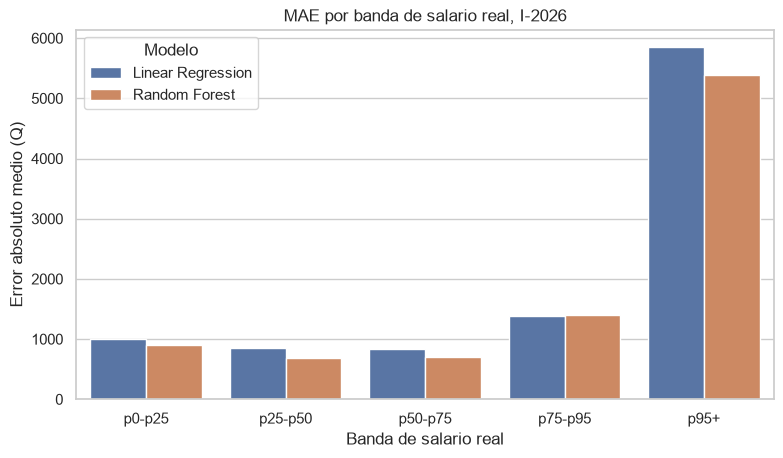

+-----------------+------------------------------+----------------------------------+-----------------------+-------------------+-----------------+---------+
|MAE_p95_mas      |MAE_promedio_bandas_inferiores|delta_MAE_p95_mas_menos_inferiores|direccion_error_p95_mas|error_medio_p95_mas|modelo           |n_p95_mas|
+-----------------+------------------------------+----------------------------------+-----------------------+-------------------+-----------------+---------+
|5848.388653995689|1015.5915650660584            |4832.797088929631                 |subestimación          |5645.339200322463  |Linear Regression|643      |
|5395.377014588168|924.1227151800315             |4471.254299408137                 |subestimación          |5186.301802413602  |Random Forest    |643      |
+-----------------+------------------------------+----------------------------------+-----------------------+-------------------+-----------------+---------+



**Salarios altos.** En la banda p95+, Linear Regression: MAE p95+ Q5,848.39, mayor que el promedio inferior por Q4,832.80; subestimación media Q5,645.34; Random Forest: MAE p95+ Q5,395.38, mayor que el promedio inferior por Q4,471.25; subestimación media Q5,186.30. La conclusión compara explícitamente p95+ con el promedio de las bandas inferiores; un error medio positivo identifica subestimación promedio en ese segmento.

In [24]:
p25, p50, p75, p95 = df_2026_prepared.approxQuantile(
    "salario_mensual", [0.25, 0.50, 0.75, 0.95], 0.001
)

def add_salary_band(frame):
    return frame.withColumn(
        "banda_salario",
        F.when(F.col("salario_mensual") <= F.lit(p25), F.lit("p0-p25"))
        .when(F.col("salario_mensual") <= F.lit(p50), F.lit("p25-p50"))
        .when(F.col("salario_mensual") <= F.lit(p75), F.lit("p50-p75"))
        .when(F.col("salario_mensual") <= F.lit(p95), F.lit("p75-p95"))
        .otherwise(F.lit("p95+")),
    )

def salary_band_metrics(frame, model_name):
    return (
        add_salary_band(frame).groupBy("banda_salario")
        .agg(
            F.count("*").alias("n"),
            F.avg("salario_mensual").alias("salario_medio"),
            F.percentile_approx("salario_mensual", 0.5, 10_000).alias("salario_mediano"),
            F.avg("prediction").alias("prediccion_media"),
            F.avg(F.abs(F.col("residuo"))).alias("MAE"),
            F.sqrt(F.avg(F.pow(F.col("residuo"), 2))).alias("RMSE"),
            F.avg("residuo").alias("error_medio"),
            F.avg(F.abs(F.col("residuo"))).alias("error_medio_absoluto"),
        )
        .withColumn("modelo", F.lit(model_name))
        .select(
            "modelo", "banda_salario", "n", "salario_medio", "salario_mediano",
            "prediccion_media", "MAE", "RMSE", "error_medio", "error_medio_absoluto",
        )
    )

errors_by_salary_band = salary_band_metrics(
    pred_lr_2026_error, "Linear Regression"
).unionByName(salary_band_metrics(pred_rf_2026_error, "Random Forest"))
band_order = F.when(F.col("banda_salario") == "p0-p25", 1).when(
    F.col("banda_salario") == "p25-p50", 2
).when(F.col("banda_salario") == "p50-p75", 3).when(
    F.col("banda_salario") == "p75-p95", 4
).otherwise(5)
errors_by_salary_band = errors_by_salary_band.orderBy("modelo", band_order)
errors_by_salary_band.show(truncate=False)
write_small_table(errors_by_salary_band, TABLES / "errors_by_salary_band.csv")

salary_band_pd = aggregate_to_pandas(errors_by_salary_band)
band_labels = ["p0-p25", "p25-p50", "p50-p75", "p75-p95", "p95+"]
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=salary_band_pd,
    x="banda_salario",
    y="MAE",
    hue="modelo",
    order=band_labels,
    ax=ax,
)
ax.set_title("MAE por banda de salario real, I-2026")
ax.set_xlabel("Banda de salario real")
ax.set_ylabel("Error absoluto medio (Q)")
ax.legend(title="Modelo")
save_figure(fig, "mae_por_banda_salario_2026.png")
plt.show()
high_salary_rows = []
high_notes = []
for model_name in ("Linear Regression", "Random Forest"):
    model_bands = salary_band_pd.loc[salary_band_pd["modelo"] == model_name]
    high_row = model_bands.loc[model_bands["banda_salario"] == "p95+"].iloc[0]
    lower_bands = model_bands.loc[model_bands["banda_salario"] != "p95+"]
    lower_mean_mae = float(lower_bands["MAE"].mean())
    high_mae = float(high_row["MAE"])
    mae_delta = high_mae - lower_mean_mae
    direction = "subestimación" if high_row["error_medio"] > 0 else "sobreestimación"
    mae_comparison = "mayor" if mae_delta > 0 else "menor" if mae_delta < 0 else "igual"
    high_salary_rows.append({
        "modelo": model_name,
        "n_p95_mas": int(high_row["n"]),
        "MAE_p95_mas": high_mae,
        "MAE_promedio_bandas_inferiores": lower_mean_mae,
        "delta_MAE_p95_mas_menos_inferiores": mae_delta,
        "error_medio_p95_mas": float(high_row["error_medio"]),
        "direccion_error_p95_mas": direction,
    })
    high_notes.append(
        f"{model_name}: MAE p95+ Q{high_mae:,.2f}, {mae_comparison} que el promedio inferior por Q{abs(mae_delta):,.2f}; "
        f"{direction} media Q{abs(float(high_row['error_medio'])):,.2f}"
    )
high_salary_comparison = spark.createDataFrame(high_salary_rows).orderBy("modelo")
high_salary_comparison.show(truncate=False)
write_small_table(high_salary_comparison, TABLES / "high_salary_comparison.csv")
display(Markdown(
    "**Salarios altos.** En la banda p95+, " + "; ".join(high_notes) + ". "
    "La conclusión compara explícitamente p95+ con el promedio de las bandas inferiores; "
    "un error medio positivo identifica subestimación promedio en ese segmento."
))


# Discusión final


In [25]:
discussion = f'''
En los registros analizados, los filtros conservaron {n_2025_prepared:,} de {n_2025_raw:,}
filas de 2025 y {n_2026_prepared:,} de {n_2026_raw:,} de I-2026. Los salarios extremos no
se eliminaron: la media salarial de 2025 fue Q{salary_mean_2025:,.2f} y la mediana
Q{salary_median_2025:,.2f}, por lo que ambas medidas se reportan para mostrar la forma de la
distribución. La categoría ocupacional más frecuente fue
{categorical_leaders['categoria_ocupacional_etiqueta']['categoria']}
({categorical_leaders['categoria_ocupacional_etiqueta']['porcentaje']:.2f}%) y el cambio
observado en la mediana entre {temporal_first['periodo_archivo']} y
{temporal_last['periodo_archivo']} fue Q{temporal_median_delta:,.2f}.

La asociación lineal de mayor magnitud con salario fue {strongest_variable}
(r = {strongest_value:.3f}); la relación edad-antigüedad se muestra en la matriz, sin
interpretarla como causal. KMeans seleccionó K = {best_k} con silhouette
{best_silhouette:.4f}, usando únicamente edad, antigüedad y horas. El cluster más grande fue
el {int(largest_cluster['cluster'])}, con {int(largest_cluster['n']):,} registros
({largest_cluster['porcentaje']:.2f}%).

{"; ".join(performance_notes)}. El menor RMSE de validación fue
{validation_winner['modelo']} (Q{validation_winner['RMSE']:,.2f}) y el menor RMSE de test
fue {test_winner['modelo']} (Q{test_winner['RMSE']:,.2f}). La comparación temporal produjo:
{"; ".join(stability_notes)}. Estas variaciones se describen como estabilidad o degradación
entre períodos, y no se usaron para seleccionar hiperparámetros.

Por segmentos, {"; ".join(segment_error_notes)}. En salarios altos,
{"; ".join(high_notes)}. El signo del error medio de p95+ determina si se observó
subestimación o sobreestimación promedio, sin afirmar que una característica determine el
salario. Los resultados son predictivos, observacionales y no ponderados.
'''
display(Markdown(dedent(discussion)))



En los registros analizados, los filtros conservaron 53,025 de 203,676
filas de 2025 y 13,258 de 49,843 de I-2026. Los salarios extremos no
se eliminaron: la media salarial de 2025 fue Q3,421.68 y la mediana
Q3,000.00, por lo que ambas medidas se reportan para mostrar la forma de la
distribución. La categoría ocupacional más frecuente fue
2 - Empleado de empresa privada
(54.13%) y el cambio
observado en la mediana entre 2025T1 y
2025T4 fue Q200.00.

La asociación lineal de mayor magnitud con salario fue antiguedad
(r = 0.180); la relación edad-antigüedad se muestra en la matriz, sin
interpretarla como causal. KMeans seleccionó K = 2 con silhouette
0.5545, usando únicamente edad, antigüedad y horas. El cluster más grande fue
el 1, con 38,421 registros
(72.46%).

Baseline: validación MAE/RMSE Q1,690.10/Q2,996.48; I-2026 Q1,718.68/Q2,923.08; Linear Regression: validación MAE/RMSE Q1,245.32/Q2,294.28; I-2026 Q1,240.71/Q2,163.75; Random Forest: validación MAE/RMSE Q1,134.70/Q2,176.62; I-2026 Q1,130.41/Q2,016.76. El menor RMSE de validación fue
Random Forest (Q2,176.62) y el menor RMSE de test
fue Random Forest (Q2,016.76). La comparación temporal produjo:
Baseline: RMSE disminuyó Q73.40; Linear Regression: RMSE disminuyó Q130.53; Random Forest: RMSE disminuyó Q159.85. Estas variaciones se describen como estabilidad o degradación
entre períodos, y no se usaron para seleccionar hiperparámetros.

Por segmentos, Linear Regression: mayor MAE por educación en `7` (Q12,919.31; n=12) y por dominio en `1` (Q1,446.09; n=5,632); Random Forest: mayor MAE por educación en `7` (Q12,824.93; n=12) y por dominio en `1` (Q1,340.30; n=5,632). En salarios altos,
Linear Regression: MAE p95+ Q5,848.39, mayor que el promedio inferior por Q4,832.80; subestimación media Q5,645.34; Random Forest: MAE p95+ Q5,395.38, mayor que el promedio inferior por Q4,471.25; subestimación media Q5,186.30. El signo del error medio de p95+ determina si se observó
subestimación o sobreestimación promedio, sin afirmar que una característica determine el
salario. Los resultados son predictivos, observacionales y no ponderados.


# Conclusiones


In [26]:
conclusions = [
    f"Se armonizaron cuatro períodos de Personas ENEIC 2025 con {n_2025_raw:,} registros originales y {n_2025_prepared:,} elegibles después de los filtros documentados.",
    f"La media salarial de 2025 fue Q{salary_mean_2025:,.2f} y la mediana Q{salary_median_2025:,.2f}; los extremos se conservaron en las métricas principales.",
    f"La mayor asociación lineal con salario fue {strongest_variable} (r = {strongest_value:.3f}), una asociación descriptiva y no causal.",
    f"KMeans seleccionó K = {best_k} con silhouette {best_silhouette:.4f}; el cluster más grande concentró {largest_cluster['porcentaje']:.2f}% de los registros y no usó salario como entrada.",
    f"En validación 2025, {validation_winner['modelo']} obtuvo el menor RMSE: Q{validation_winner['RMSE']:,.2f}; en I-2026 el menor RMSE fue {test_winner['modelo']}: Q{test_winner['RMSE']:,.2f}.",
    "La comparación validación→test mostró: " + "; ".join(stability_notes) + ".",
    "Los errores por educación y dominio variaron por segmento; " + "; ".join(high_notes) + ".",
    "El análisis no es ponderado; FACTOR se conserva para usos de estimación poblacional que incorporen el diseño de encuesta.",
]
display(Markdown("\n".join(f"{index + 1}. {item}" for index, item in enumerate(conclusions))))


1. Se armonizaron cuatro períodos de Personas ENEIC 2025 con 203,676 registros originales y 53,025 elegibles después de los filtros documentados.
2. La media salarial de 2025 fue Q3,421.68 y la mediana Q3,000.00; los extremos se conservaron en las métricas principales.
3. La mayor asociación lineal con salario fue antiguedad (r = 0.180), una asociación descriptiva y no causal.
4. KMeans seleccionó K = 2 con silhouette 0.5545; el cluster más grande concentró 72.46% de los registros y no usó salario como entrada.
5. En validación 2025, Random Forest obtuvo el menor RMSE: Q2,176.62; en I-2026 el menor RMSE fue Random Forest: Q2,016.76.
6. La comparación validación→test mostró: Baseline: RMSE disminuyó Q73.40; Linear Regression: RMSE disminuyó Q130.53; Random Forest: RMSE disminuyó Q159.85.
7. Los errores por educación y dominio variaron por segmento; Linear Regression: MAE p95+ Q5,848.39, mayor que el promedio inferior por Q4,832.80; subestimación media Q5,645.34; Random Forest: MAE p95+ Q5,395.38, mayor que el promedio inferior por Q4,471.25; subestimación media Q5,186.30.
8. El análisis no es ponderado; FACTOR se conserva para usos de estimación poblacional que incorporen el diseño de encuesta.

# Limitaciones

- Los datos son observacionales, por lo que las asociaciones y modelos
  no establecen causalidad ni determinan cuánto “debería” ganar alguien.
- El análisis es no ponderado; `FACTOR` no se usó para estimaciones
  poblacionales con diseño muestral.
- Los salarios extremos se conservan y pueden influir notablemente en
  RMSE y en los errores de la parte alta de la distribución.
- Las categorías ausentes o no interpretables se representan como
  `DESCONOCIDO`, lo que limita la interpretación de esos grupos.
- La ENEIC tiene diseño longitudinal y puede haber dependencias entre
  observaciones o cambios de composición entre períodos.
- El cambio temporal 2025→2026 puede modificar el desempeño, que
  también puede variar fuera de estas muestras y períodos.
